# 19. Causal Report Generation with LLMs

A causal analysis is not finished when the model runs. It is finished when a decision-maker can understand what was estimated, why the design is credible, what uncertainty remains, and what action is justified.

This notebook studies how LLMs can help write causal reports without turning careful evidence into overconfident storytelling. The core idea is simple: give the model a structured evidence package, constrain the output schema, and audit the language for causal overclaiming.

## Mathematical Core

A causal report should preserve the chain from estimand to recommendation. One way to formalize report quality is

$$
S(r) = w_1 S_{\mathrm{estimand}}(r) + w_2 S_{\mathrm{identification}}(r) + w_3 S_{\mathrm{diagnostics}}(r) + w_4 S_{\mathrm{decision}}(r).
$$

The effect estimate still has the usual structure,

$$
\hat\tau \pm z_{1-\alpha/2}\widehat{\mathrm{se}}(\hat\tau).
$$

The report should explain what this interval means for the decision, which assumptions support it, and which diagnostics weaken confidence. The LLM is useful when it improves structure without loosening the statistical contract.


## Learning Goals

By the end of this notebook, you should be able to:

- Build a machine-readable evidence package from estimates, diagnostics, assumptions, and limitations.
- Separate executive reporting from technical reporting without changing the underlying causal claim.
- Use deterministic templates as a baseline before asking an LLM to draft text.
- Ask local LLMs to produce structured causal reports from tables and diagnostics.
- Audit generated reports for overclaiming, missing uncertainty, missing estimands, and missing threats to validity.
- Compare models on report quality instead of treating fluent prose as evidence of causal understanding.

## Live Model Note

Report generation notebooks are brittle in a specific way: the most fluent model output is often the most dangerous output. A model may smooth over uncertainty, convert an intent-to-treat estimate into a treatment-on-the-treated claim, drop guardrails, omit noncompliance, or recommend action that the design does not support.

That brittleness is part of the lesson. We will keep deterministic estimates and diagnostics separate from generated prose, then score the prose. If your live outputs differ across reruns or model families, treat that variation as evidence about the reporting system, not as noise to ignore.

## 1. Setup

The notebook uses a synthetic randomized encouragement study. The randomized assignment lets us focus on report generation rather than identification complexity, but the reporting discipline generalizes to observational adjustment, quasi-experiments, CML, and policy evaluation.

In [1]:
# Section focus: 1. Setup.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import importlib.util
import json
import re
import sys
import textwrap
import warnings
from copy import deepcopy
from pathlib import Path
from typing import Any, Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from IPython.display import Markdown, display
from pydantic import BaseModel, Field

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')

PROJECT_ROOT = Path.cwd()
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'notebooks' / '_shared' / 'local_llm.py').exists():
        PROJECT_ROOT = candidate
        break

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')

from notebooks._shared.display import smart_display


Project root: repository root


In [2]:
RUN_LIVE_LOCAL_LLM = True
RUN_FULL_MODEL_COMPARISON = True
RUN_SCHEMA_REPAIR_RETRY = True

MODEL_ID = 'Qwen/Qwen2.5-14B-Instruct'
MAX_NEW_TOKENS = 2100
COMPACT_MAX_NEW_TOKENS = 900
TEMPERATURE = 0.0
SEED = 219
MODEL_COMPARISON_CASE_LIMIT = 3

try:
    import torch
    print(f'CUDA available to this kernel: {torch.cuda.is_available()}')
except Exception as exc:
    print(f'Torch availability check failed: {exc}')

CUDA available to this kernel: True


In [3]:
try:
    from notebooks._shared.local_llm import DEFAULT_MODELS_TO_COMPARE, get_device
except Exception:
    DEFAULT_MODELS_TO_COMPARE = [
        ('Qwen 14B', MODEL_ID, 'strong local analysis'),
    ]

MODELS_TO_COMPARE = DEFAULT_MODELS_TO_COMPARE
pd.DataFrame(MODELS_TO_COMPARE, columns=['label', 'model_id', 'role'])

,label,model_id,role
0,Qwen 0.5B,Qwen/Qwen2.5-0.5B-Instruct,pipeline smoke test
1,Qwen 7B,Qwen/Qwen2.5-7B-Instruct,fast default
2,Qwen 14B,Qwen/Qwen2.5-14B-Instruct,strong local analysis
3,Qwen 32B,Qwen/Qwen2.5-32B-Instruct,scale comparison
4,Phi mini,microsoft/Phi-3.5-mini-instruct,compact non-Qwen comparison
5,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison
6,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison
7,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison
8,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline


## 2. What Is a Causal Report?

A causal report is a decision document, not a prettier regression table. It is a decision document that maps evidence to action.

A good causal report answers six questions:

1. What decision is being considered?
2. What estimand was targeted?
3. What design identifies that estimand?
4. What did the analysis estimate, with uncertainty?
5. What diagnostics make the design more or less credible?
6. What action is justified, and what should not be claimed?

LLMs can help with the writing, but they should not be allowed to invent the evidence. The safest workflow is:

$$
\text{analysis outputs} \rightarrow \text{structured evidence package} \rightarrow \text{draft report} \rightarrow \text{language audit}
$$

## 3. Running Example: Proactive Onboarding Outreach

Suppose a SaaS company tests whether proactive onboarding outreach improves activation for new trial accounts.

The business wants to know whether it should expand the outreach playbook. The causal team ran a randomized encouragement design:

- Trial accounts were randomly assigned to receive an invitation for a guided onboarding session.
- Some invited accounts did not attend.
- Some non-invited accounts still found help through normal support channels.
- The primary estimand is the intent-to-treat effect of assignment to outreach.
- A secondary compliance-adjusted estimand approximates the effect for customers induced to attend because of assignment.

This is a common reporting trap. The assignment effect is not the same as the effect of actually attending the session. A report that says "the session caused X" from an assignment analysis is overstating the evidence.

In [4]:
report_contract = {
    'analysis_id': 'saas_onboarding_outreach_rct_v1',
    'decision': 'Should the company expand proactive onboarding outreach to all eligible trial accounts?',
    'business_question': 'What is the effect of being assigned to proactive onboarding outreach on 30-day activation?',
    'primary_estimand': 'Intent-to-treat effect of assignment to outreach on 30-day activation',
    'secondary_estimand': 'Approximate complier effect using assignment as an encouragement for session attendance',
    'unit': 'trial account',
    'treatment_assignment': 'randomized invitation to guided onboarding outreach',
    'primary_outcome': 'activated_30d',
    'secondary_outcome': 'revenue_30d',
    'guardrail_outcomes': ['support_tickets_30d', 'refund_request_30d'],
    'design': 'stratified randomized encouragement design',
    'known_reporting_risks': [
        'Do not describe the ITT as the effect of attending the session.',
        'Do not ignore noncompliance or missing 30-day outcomes.',
        'Do not recommend full rollout if guardrails move in a harmful direction.',
        'Do not treat synthetic ground truth as something available in a real report.',
    ],
}

print(json.dumps(report_contract, indent=2))

{
  "analysis_id": "saas_onboarding_outreach_rct_v1",
  "decision": "Should the company expand proactive onboarding outreach to all eligible trial accounts?",
  "business_question": "What is the effect of being assigned to proactive onboarding outreach on 30-day activation?",
  "primary_estimand": "Intent-to-treat effect of assignment to outreach on 30-day activation",
  "secondary_estimand": "Approximate complier effect using assignment as an encouragement for session attendance",
  "unit": "trial account",
  "treatment_assignment": "randomized invitation to guided onboarding outreach",
  "primary_outcome": "activated_30d",
  "secondary_outcome": "revenue_30d",
  "guardrail_outcomes": [
    "support_tickets_30d",
    "refund_request_30d"
  ],
  "design": "stratified randomized encouragement design",
  "known_reporting_risks": [
    "Do not describe the ITT as the effect of attending the session.",
    "Do not ignore noncompliance or missing 30-day outcomes.",
    "Do not recommend ful

Running Example: Proactive Onboarding Outreach should make the design easier to audit, not easier to hand-wave.


## 4. Simulating an Evidence-Producing Study

The simulation includes practical complications that a report must mention:

- Account segments differ in baseline activation.
- Assignment is randomized within the study, but attendance is not perfectly compliant.
- Some 30-day outcomes are missing.
- Outreach increases activation, but it also slightly increases short-run support demand.

The report should therefore say something like: "Assignment to outreach increased activation by about X percentage points" rather than "onboarding sessions always make customers successful."

The simulated study is designed to produce the ingredients of a real causal report: assignment, compliance, main outcome, guardrails, missingness, balance checks, and uncertainty. The study is randomized, which keeps identification relatively clean, but imperfect attendance and missing outcomes create reporting issues that a memo must not hide.

The experiment is about report discipline. We compare deterministic reporting with LLM-drafted reporting and ask whether the model preserves the estimand, includes guardrails, names limitations, and avoids overclaiming. The dataset is simple enough to audit but rich enough to expose dangerous reporting shortcuts.


In [5]:
# Section focus: 4. Simulating an Evidence-Producing Study.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def sigmoid(x):
    """Map a linear score to a probability-like value for the notebook simulation.
    
    Parameters
    ----------
    x : object
        Numeric score, scalar, or array passed through the transformation in this helper.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the sigmoid calculation.
    """
    return 1 / (1 + np.exp(-x))


def simulate_onboarding_experiment(n=6800, seed=SEED):
    """Create a simulated onboarding experiment data set for the 19. Causal Report Generation with LLMs case study.
    
    Parameters
    ----------
    n : object
        Number of observations or simulation units used by the calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(seed)
    segments = np.array(['self_serve', 'startup', 'mid_market', 'enterprise'])
    segment = rng.choice(segments, size=n, p=[0.35, 0.28, 0.25, 0.12])
    week = rng.integers(1, 13, size=n)

    segment_activation = {
        'self_serve': -0.35,
        'startup': -0.05,
        'mid_market': 0.20,
        'enterprise': 0.05,
    }
    segment_revenue = {
        'self_serve': 45,
        'startup': 95,
        'mid_market': 210,
        'enterprise': 520,
    }

    log_company_size = rng.normal(2.8, 0.85, size=n)
    prior_intent = rng.normal(0, 1, size=n) + np.select(
        [segment == 'enterprise', segment == 'mid_market', segment == 'startup'],
        [0.15, 0.10, 0.05],
        default=-0.05,
    )
    baseline_product_usage = np.maximum(0, rng.normal(4.5 + 0.9 * prior_intent, 1.4, size=n))

    assigned_outreach = rng.binomial(1, 0.5, size=n)

    attendance_logit = (
        -1.25
        + 1.65 * assigned_outreach
        + 0.35 * prior_intent
        + 0.10 * (segment == 'enterprise')
        + 0.04 * (week - 6)
    )
    attendance_probability = sigmoid(attendance_logit)
    attended_session = rng.binomial(1, attendance_probability)

    base_activation_logit = (
        -0.75
        + np.vectorize(segment_activation.get)(segment)
        + 0.48 * prior_intent
        + 0.13 * baseline_product_usage
        + 0.05 * (week - 6)
    )
    activation_effect_logit = 0.55 * attended_session + 0.08 * assigned_outreach
    activated_probability = sigmoid(base_activation_logit + activation_effect_logit)
    activated_30d = rng.binomial(1, activated_probability)

    revenue_base = np.vectorize(segment_revenue.get)(segment)
    revenue_noise = rng.normal(0, 35 + 0.18 * revenue_base, size=n)
    revenue_30d = np.maximum(
        0,
        revenue_base * (0.25 + 0.85 * activated_30d) + 18 * assigned_outreach + 42 * attended_session + revenue_noise,
    )

    support_rate = np.exp(-0.15 + 0.18 * assigned_outreach + 0.25 * attended_session + 0.08 * baseline_product_usage)
    support_tickets_30d = rng.poisson(np.clip(support_rate, 0.05, 8.0))

    refund_logit = -3.25 - 0.25 * activated_30d + 0.20 * (support_tickets_30d > 3) - 0.08 * assigned_outreach
    refund_request_30d = rng.binomial(1, sigmoid(refund_logit))

    observed_logit = 3.55 - 0.18 * (segment == 'self_serve') - 0.05 * assigned_outreach + 0.05 * prior_intent
    observed_30d = rng.binomial(1, sigmoid(observed_logit))

    df = pd.DataFrame({
        'account_id': np.arange(n),
        'segment': segment,
        'week': week,
        'log_company_size': log_company_size,
        'prior_intent': prior_intent,
        'baseline_product_usage': baseline_product_usage,
        'assigned_outreach': assigned_outreach,
        'attended_session': attended_session,
        'attendance_probability': attendance_probability,
        'activated_30d': activated_30d.astype(float),
        'revenue_30d': revenue_30d,
        'support_tickets_30d': support_tickets_30d.astype(float),
        'refund_request_30d': refund_request_30d.astype(float),
        'observed_30d': observed_30d,
    })

    outcome_cols = ['activated_30d', 'revenue_30d', 'support_tickets_30d', 'refund_request_30d']
    for col in outcome_cols:
        df.loc[df['observed_30d'] == 0, col] = np.nan

    return df


df = simulate_onboarding_experiment()
df.head()

,account_id,segment,week,log_company_size,prior_intent,baseline_product_usage,assigned_outreach,attended_session,attendance_probability,activated_30d,revenue_30d,support_tickets_30d,refund_request_30d,observed_30d
0,0,mid_market,9,3.633949,0.529589,3.082827,0,1,0.279963,1.0,317.150415,2.0,0.0,1
1,1,self_serve,12,2.779666,-0.525062,3.719083,0,0,0.232585,1.0,22.763035,0.0,0.0,1
2,2,mid_market,7,1.998001,1.174127,5.554548,1,1,0.700765,1.0,157.656667,2.0,0.0,1
3,3,enterprise,3,3.764419,-0.424954,4.842793,0,0,0.194860,1.0,384.703775,1.0,0.0,1
4,4,self_serve,3,3.457215,0.098262,5.971158,0,0,0.208233,0.0,0.000000,2.0,0.0,1


In Simulating an Evidence-Producing Study, the response earns credit by being specific, cautious, and easy to audit.


In [6]:
summary_table = (
    df.assign(assigned_label=lambda d: np.where(d['assigned_outreach'] == 1, 'assigned outreach', 'control'))
    .groupby('assigned_label')
    .agg(
        accounts=('account_id', 'size'),
        observed_30d=('observed_30d', 'mean'),
        attended_session=('attended_session', 'mean'),
        activated_30d=('activated_30d', 'mean'),
        revenue_30d=('revenue_30d', 'mean'),
        support_tickets_30d=('support_tickets_30d', 'mean'),
        refund_request_30d=('refund_request_30d', 'mean'),
    )
    .reset_index()
)
smart_display(summary_table)

,assigned_label,accounts,observed_30d,attended_session,activated_30d,revenue_30d,support_tickets_30d,refund_request_30d
0,assigned outreach,3388,0.969599,0.600649,0.545510,166.418050,1.789954,0.029528
1,control,3412,0.973329,0.234467,0.473653,123.789265,1.383017,0.032219


Read Simulating an Evidence-Producing Study for discipline. The workflow is easier to audit when evidence, uncertainty, and assumptions are separated.


## 5. Balance and Missingness Diagnostics

The report should show the treatment effect and whether the design behaved as expected.

For a randomized study, we want balance on pre-treatment covariates and similar outcome-observation rates across arms. Perfect balance is not required, but large imbalances create communication and analysis risks.

In [7]:
# Section focus: 5. Balance and Missingness Diagnostics.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def standardized_difference(data, covariate, treatment='assigned_outreach'):
    """Carry out the standardized difference step used in the 19. Causal Report Generation with LLMs workflow.
    
    Parameters
    ----------
    data : object
        Input data set used by this step of the notebook.
    covariate : object
        Single adjustment or feature column being inspected in the diagnostic.
    treatment : object
        Treatment or intervention indicator used by the causal workflow.
    
    Returns
    -------
    object
        Intermediate result produced by the standardized difference calculation and reused by later cells.
    """
    treated = data.loc[data[treatment] == 1, covariate].dropna()
    control = data.loc[data[treatment] == 0, covariate].dropna()
    pooled_sd = np.sqrt((treated.var(ddof=1) + control.var(ddof=1)) / 2)
    if pooled_sd == 0 or np.isnan(pooled_sd):
        return 0.0
    return (treated.mean() - control.mean()) / pooled_sd


def build_balance_table(data, covariates):
    """Build the balance table object used in the 19. Causal Report Generation with LLMs analysis.
    
    Parameters
    ----------
    data : object
        Input data set used by this step of the notebook.
    covariates : object
        Adjustment or feature columns representing observed pre-decision information.
    
    Returns
    -------
    object
        Tabular or matrix-style object produced by the balance table workflow for later analysis.
    """
    rows = []
    for covariate in covariates:
        rows.append({
            'covariate': covariate,
            'control_mean': data.loc[data['assigned_outreach'] == 0, covariate].mean(),
            'assigned_mean': data.loc[data['assigned_outreach'] == 1, covariate].mean(),
            'std_diff': standardized_difference(data, covariate),
        })
    out = pd.DataFrame(rows)
    out['status'] = np.where(out['std_diff'].abs() <= 0.10, 'pass', 'review')
    return out


balance_table = build_balance_table(
    df,
    ['log_company_size', 'prior_intent', 'baseline_product_usage'],
)
smart_display(balance_table)

,covariate,control_mean,assigned_mean,std_diff,status
0,log_company_size,2.785835,2.814202,0.033940,pass
1,prior_intent,0.073141,0.028980,-0.043972,pass
2,baseline_product_usage,4.562294,4.530268,-0.018997,pass


For Balance and Missingness Diagnostics, use the output to see whether the model respected the design contract or blurred it.


In [8]:
missingness_table = (
    df.assign(assigned_label=lambda d: np.where(d['assigned_outreach'] == 1, 'assigned outreach', 'control'))
    .groupby('assigned_label')
    .agg(observed_rate=('observed_30d', 'mean'), missing_rate=('observed_30d', lambda x: 1 - x.mean()))
    .reset_index()
)

missing_diff = (
    df.loc[df['assigned_outreach'] == 1, 'observed_30d'].mean()
    - df.loc[df['assigned_outreach'] == 0, 'observed_30d'].mean()
)
missingness_table, missing_diff

(      assigned_label  observed_rate  missing_rate
 0  assigned outreach       0.969599      0.030401
 1            control       0.973329      0.026671,
 np.float64(-0.003730842321911343))

For Balance and Missingness Diagnostics, treat the response as a small experiment in model behavior. The workflow should keep the useful draft while documenting where it broke.


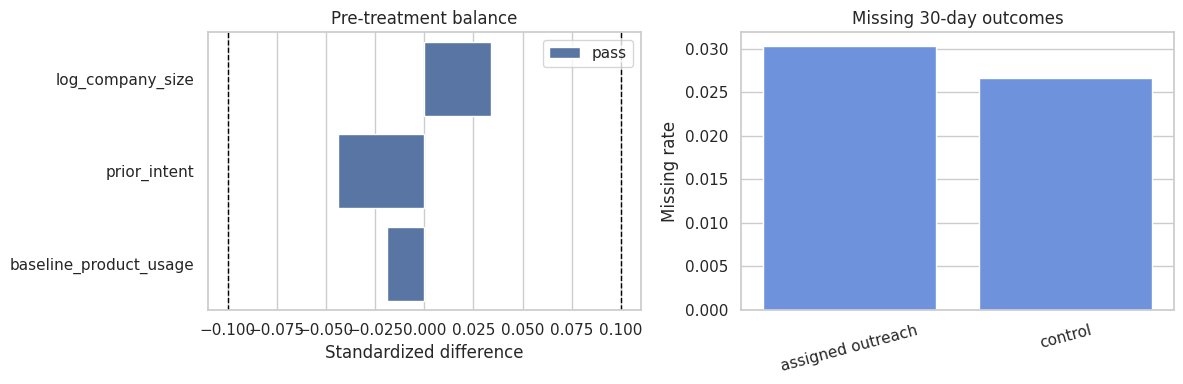

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=balance_table, x='std_diff', y='covariate', hue='status', dodge=False, ax=axes[0])
axes[0].axvline(-0.10, color='black', linestyle='--', linewidth=1)
axes[0].axvline(0.10, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Pre-treatment balance')
axes[0].set_xlabel('Standardized difference')
axes[0].set_ylabel('')
axes[0].legend(title='')

sns.barplot(data=missingness_table, x='assigned_label', y='missing_rate', ax=axes[1], color='#5B8DEF')
axes[1].set_title('Missing 30-day outcomes')
axes[1].set_xlabel('')
axes[1].set_ylabel('Missing rate')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

For Balance and Missingness Diagnostics, weak output is useful only if it tells us which part of the workflow needs a stronger check.


## 6. Estimating the Main Effects

The primary report estimate is an intent-to-treat effect:

$$
\mathbb{E}[Y_i(1) - Y_i(0)]
$$

where treatment is assignment to outreach, not actual attendance. Because assignment is randomized, a simple adjusted regression is used for precision and for easier reporting by segment and week.

In [10]:
# Section focus: 6. Estimating the Main Effects.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def fit_adjusted_effect(data, outcome, treatment='assigned_outreach', covariates=('C(segment)', 'C(week)')):
    """Fit the adjusted effect model or object used in the 19. Causal Report Generation with LLMs analysis.
    
    Parameters
    ----------
    data : object
        Input data set used by this step of the notebook.
    outcome : object
        Outcome variable whose behavior is being modeled or compared.
    treatment : object
        Treatment or intervention indicator used by the causal workflow.
    covariates : object
        Adjustment or feature columns representing observed pre-decision information.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    formula = f"{outcome} ~ {treatment} + " + ' + '.join(covariates)
    model = smf.ols(formula, data=data).fit(cov_type='HC1')
    term = treatment
    return {
        'outcome': outcome,
        'estimand': 'ITT' if treatment == 'assigned_outreach' else f'effect of {treatment}',
        'formula': formula,
        'estimate': float(model.params[term]),
        'std_error': float(model.bse[term]),
        'ci_low': float(model.conf_int().loc[term, 0]),
        'ci_high': float(model.conf_int().loc[term, 1]),
        'p_value': float(model.pvalues[term]),
        'n_obs': int(model.nobs),
    }


def fit_unadjusted_difference(data, outcome):
    """Fit the unadjusted difference model or object used in the 19. Causal Report Generation with LLMs analysis.
    
    Parameters
    ----------
    data : object
        Input data set used by this step of the notebook.
    outcome : object
        Outcome variable whose behavior is being modeled or compared.
    
    Returns
    -------
    object
        Intermediate result produced by the unadjusted difference calculation and reused by later cells.
    """
    observed = data[[outcome, 'assigned_outreach']].dropna()
    assigned_mean = observed.loc[observed['assigned_outreach'] == 1, outcome].mean()
    control_mean = observed.loc[observed['assigned_outreach'] == 0, outcome].mean()
    return float(assigned_mean - control_mean)


estimate_rows = []
for outcome in ['activated_30d', 'revenue_30d', 'support_tickets_30d', 'refund_request_30d']:
    result = fit_adjusted_effect(df, outcome)
    result['unadjusted_difference'] = fit_unadjusted_difference(df, outcome)
    estimate_rows.append(result)

estimate_table = pd.DataFrame(estimate_rows)
estimate_table[['outcome', 'estimate', 'std_error', 'ci_low', 'ci_high', 'p_value', 'unadjusted_difference', 'n_obs']]

,outcome,estimate,std_error,ci_low,ci_high,p_value,unadjusted_difference,n_obs
0,activated_30d,0.070620,0.012156,0.046794,0.094446,6.274464e-09,0.071857,6606
1,revenue_30d,42.540045,2.791880,37.068061,48.012030,2.006985e-52,42.628785,6606
2,support_tickets_30d,0.405965,0.031809,0.343619,0.468310,2.659062e-37,0.406937,6606
3,refund_request_30d,-0.002752,0.004283,-0.011146,0.005642,5.204334e-01,-0.002691,6606


In Estimating the Main Effects, the response is useful only if a human analyst can check it. The first review question is whether the answer stayed anchored to the evidence.


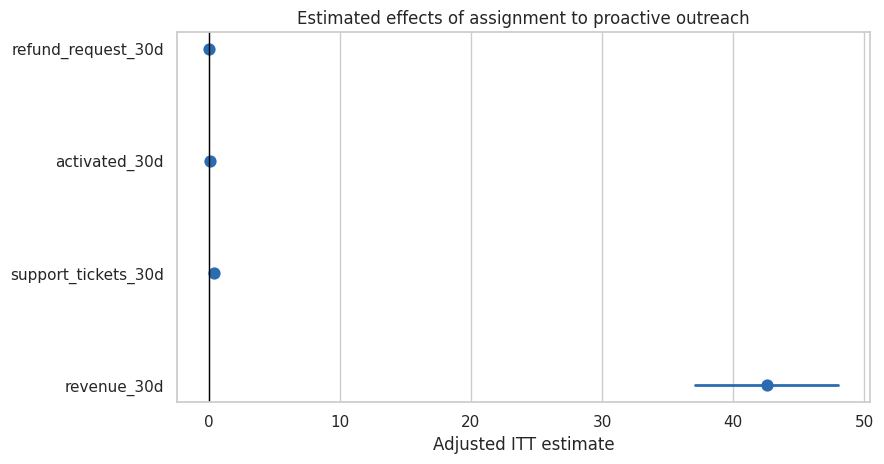

In [11]:
# Section focus: 6. Estimating the Main Effects.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def plot_effect_table(table, title):
    """Draw the effect table figure for the 19. Causal Report Generation with LLMs analysis.
    
    Parameters
    ----------
    table : object
        Tabular result used by this calculation or plot.
    title : object
        Title used to label the displayed result.
    
    Returns
    -------
    object
        None. The function updates a plot, display object, or notebook state as its side effect.
    """
    plot_df = table.copy()
    order = plot_df.sort_values('estimate')['outcome']
    fig, ax = plt.subplots(figsize=(9, 4.8))
    sns.pointplot(data=plot_df, x='estimate', y='outcome', order=order, linestyle='none', color='#2B6CB0', ax=ax)
    for _, row in plot_df.iterrows():
        ax.plot([row['ci_low'], row['ci_high']], [row['outcome'], row['outcome']], color='#2B6CB0', linewidth=2)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(title)
    ax.set_xlabel('Adjusted ITT estimate')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()


plot_effect_table(estimate_table, 'Estimated effects of assignment to proactive outreach')

The useful reading of Estimating the Main Effects is whether the model kept the causal question intact.


## 7. Compliance and the Difference Between ITT and Complier Effects

The report should explicitly say whether the effect is about assignment or attendance.

The first stage is the effect of assignment on attending an onboarding session:

$$
\text{First stage} = \mathbb{E}[D_i \mid Z_i=1] - \mathbb{E}[D_i \mid Z_i=0]
$$

A simple Wald ratio gives an approximate local average treatment effect for compliers:

$$
\widehat{LATE} = \frac{\widehat{ITT}_Y}{\widehat{ITT}_D}
$$

This estimate has stronger assumptions than the assignment effect. In an executive report, it should be labeled carefully.

In [12]:
first_stage = fit_adjusted_effect(df, 'attended_session')
activation_itt = estimate_table.loc[estimate_table['outcome'] == 'activated_30d'].iloc[0].to_dict()
revenue_itt = estimate_table.loc[estimate_table['outcome'] == 'revenue_30d'].iloc[0].to_dict()

wald_late_activation = activation_itt['estimate'] / first_stage['estimate']
wald_late_revenue = revenue_itt['estimate'] / first_stage['estimate']

compliance_summary = {
    'first_stage_attendance_lift': first_stage,
    'wald_late_activation_pp': float(wald_late_activation),
    'wald_late_revenue_dollars': float(wald_late_revenue),
    'interpretation_warning': 'The Wald ratio is a complier estimate under IV assumptions; it is not the same as the randomized ITT.',
}

pd.DataFrame([
    {'quantity': 'first stage: attendance', **{k: first_stage[k] for k in ['estimate', 'std_error', 'ci_low', 'ci_high', 'p_value']}},
    {'quantity': 'Wald LATE: activation', 'estimate': wald_late_activation, 'std_error': np.nan, 'ci_low': np.nan, 'ci_high': np.nan, 'p_value': np.nan},
    {'quantity': 'Wald LATE: revenue', 'estimate': wald_late_revenue, 'std_error': np.nan, 'ci_low': np.nan, 'ci_high': np.nan, 'p_value': np.nan},
])

,quantity,estimate,std_error,ci_low,ci_high,p_value
0,first stage: attendance,0.366159,0.011104,0.344396,0.387923,1.833699e-238
1,Wald LATE: activation,0.192867,NaN,NaN,NaN,NaN
2,Wald LATE: revenue,116.179033,NaN,NaN,NaN,NaN


In Compliance and the Difference Between ITT and Complier Effects, a polished answer is secondary. The design has to remain checkable.


## 8. Segment Heterogeneity for Reporting

A report often needs to say whether the effect is concentrated in particular customer groups. Heterogeneity reporting is useful, but it can also invite overinterpretation.

Good language: "Segment estimates are directionally larger for mid-market accounts, but the study was not powered for definitive segment ranking."

Bad language: "The model discovered that mid-market customers are the only segment worth targeting."

In [13]:
# Section focus: 8. Segment Heterogeneity for Reporting.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

def fit_segment_effects(data, outcome='activated_30d'):
    """Fit the segment effects model or object used in the 19. Causal Report Generation with LLMs analysis.
    
    Parameters
    ----------
    data : object
        Input data set used by this step of the notebook.
    outcome : object
        Outcome variable whose behavior is being modeled or compared.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rows = []
    for segment, group in data.groupby('segment'):
        result = fit_adjusted_effect(group, outcome, covariates=('C(week)',))
        result['segment'] = segment
        rows.append(result)
    return pd.DataFrame(rows)


segment_effects = fit_segment_effects(df)
segment_effects[['segment', 'estimate', 'std_error', 'ci_low', 'ci_high', 'p_value', 'n_obs']]

,segment,estimate,std_error,ci_low,ci_high,p_value,n_obs
0,enterprise,0.098016,0.034443,0.030509,0.165523,0.004431,819
1,mid_market,0.075905,0.024876,0.027149,0.124661,0.002278,1596
2,self_serve,0.080993,0.020171,0.041458,0.120527,0.000059,2383
3,startup,0.039336,0.023502,-0.006727,0.085399,0.094181,1808


Segment Heterogeneity for Reporting should leave a clear trail from the business question to the causal assumptions and diagnostics.


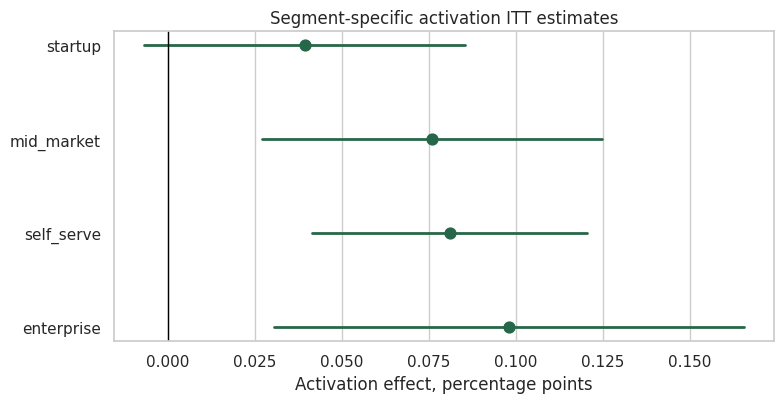

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.2))
plot_df = segment_effects.sort_values('estimate')
sns.pointplot(data=plot_df, x='estimate', y='segment', linestyle='none', color='#276749', ax=ax)
for _, row in plot_df.iterrows():
    ax.plot([row['ci_low'], row['ci_high']], [row['segment'], row['segment']], color='#276749', linewidth=2)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Segment-specific activation ITT estimates')
ax.set_xlabel('Activation effect, percentage points')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

For Segment Heterogeneity for Reporting, the useful answer is constrained and auditable. Unsupported detail, missing uncertainty, or vague assumptions should feed the next workflow revision.


## 9. Building a Machine-Readable Evidence Package

Before asking an LLM to write a report, build a structured package. This makes the report auditable.

The package should include:

- The business decision and estimand.
- The design and identification claim.
- The main estimates and confidence intervals.
- Diagnostics and their status.
- Guardrail results.
- Limitations and forbidden claims.
- Recommended action boundaries.

The LLM should be asked to transform this package, not to rediscover the analysis.

In [15]:
# Section focus: 9. Building a Machine-Readable Evidence Package.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def to_plain(value: Any):
    """Carry out the to plain step used in the 19. Causal Report Generation with LLMs workflow.
    
    Parameters
    ----------
    value : object
        Single numeric or text value being checked, transformed, or displayed by this helper.
    
    Returns
    -------
    object
        Intermediate result produced by the to plain calculation and reused by later cells.
    """
    if isinstance(value, dict):
        return {str(key): to_plain(val) for key, val in value.items()}
    if isinstance(value, list):
        return [to_plain(item) for item in value]
    if isinstance(value, tuple):
        return [to_plain(item) for item in value]
    if isinstance(value, pd.DataFrame):
        return [to_plain(row) for row in value.to_dict(orient='records')]
    if isinstance(value, pd.Series):
        return to_plain(value.to_dict())
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        if np.isnan(value):
            return None
        return float(value)
    if isinstance(value, (np.ndarray,)):
        return to_plain(value.tolist())
    return value


def diagnostic_status(balance_table, missing_diff, estimate_table):
    """Carry out the diagnostic status step used in the 19. Causal Report Generation with LLMs workflow.
    
    Parameters
    ----------
    balance_table : object
        Tabular data object used as the input or output of this workflow step.
    missing_diff : object
        The missing diff setting that controls the diagnostic status calculation in this notebook.
    estimate_table : object
        Tabular data object used as the input or output of this workflow step.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    guardrail_rows = estimate_table[estimate_table['outcome'].isin(['support_tickets_30d', 'refund_request_30d'])]
    activation_row = estimate_table.loc[estimate_table['outcome'] == 'activated_30d'].iloc[0]
    return {
        'balance': {
            'max_abs_standardized_difference': float(balance_table['std_diff'].abs().max()),
            'status': 'pass' if balance_table['std_diff'].abs().max() <= 0.10 else 'review',
        },
        'missingness': {
            'assigned_minus_control_observed_rate': float(missing_diff),
            'status': 'pass' if abs(missing_diff) <= 0.015 else 'review',
        },
        'primary_effect': {
            'status': 'positive' if activation_row['ci_low'] > 0 else 'uncertain',
            'practical_size_pp': float(100 * activation_row['estimate']),
        },
        'guardrails': [
            {
                'outcome': row['outcome'],
                'estimate': float(row['estimate']),
                'ci_low': float(row['ci_low']),
                'ci_high': float(row['ci_high']),
                'status': 'review' if row['outcome'] == 'support_tickets_30d' and row['ci_low'] > 0 else 'pass',
            }
            for _, row in guardrail_rows.iterrows()
        ],
    }


def make_evidence_package():
    """Construct the evidence package helper used in the 19. Causal Report Generation with LLMs workflow.
    
    Parameters
    ----------
    None
        This helper uses values defined in the surrounding notebook cell.
    
    Returns
    -------
    object
        Intermediate result produced by the evidence package calculation and reused by later cells.
    """
    diagnostics = diagnostic_status(balance_table, missing_diff, estimate_table)
    activation = estimate_table.loc[estimate_table['outcome'] == 'activated_30d'].iloc[0].to_dict()
    revenue = estimate_table.loc[estimate_table['outcome'] == 'revenue_30d'].iloc[0].to_dict()
    support = estimate_table.loc[estimate_table['outcome'] == 'support_tickets_30d'].iloc[0].to_dict()
    refund = estimate_table.loc[estimate_table['outcome'] == 'refund_request_30d'].iloc[0].to_dict()

    recommendation = 'expand_with_monitoring' if (
        diagnostics['primary_effect']['status'] == 'positive'
        and diagnostics['balance']['status'] == 'pass'
        and diagnostics['missingness']['status'] == 'pass'
    ) else 'needs_more_analysis'

    return to_plain({
        'contract': report_contract,
        'sample': {
            'accounts': len(df),
            'observed_30d_rate': df['observed_30d'].mean(),
            'assigned_share': df['assigned_outreach'].mean(),
        },
        'primary_result': activation,
        'secondary_result': revenue,
        'guardrail_results': [support, refund],
        'compliance': compliance_summary,
        'balance_table': balance_table.round(4),
        'missingness': {
            'table': missingness_table.round(4),
            'assigned_minus_control_observed_rate': missing_diff,
        },
        'segment_effects': segment_effects[['segment', 'estimate', 'ci_low', 'ci_high', 'p_value', 'n_obs']].round(4),
        'diagnostics': diagnostics,
        'recommended_action_boundary': recommendation,
        'must_say': [
            'The primary causal estimate is the ITT effect of assignment to outreach.',
            'The analysis supports a decision about expanding assignment to the outreach program.',
            'Attendance effects require stronger compliance assumptions.',
            'Guardrail movement in support tickets should be monitored during rollout.',
        ],
        'must_not_say': [
            'Do not say the study proves onboarding sessions caused every observed difference.',
            'Do not claim the attendance effect without labeling it as a compliance-adjusted estimate.',
            'Do not ignore missing outcomes or guardrails.',
            'Do not present segment rankings as definitive targeting rules.',
        ],
        'brittleness_note': 'LLM reports can vary across reruns and model families; generated text must be audited against this evidence package.',
    })


evidence_package = make_evidence_package()
print(json.dumps(evidence_package, indent=2)[:4500])

{
  "contract": {
    "analysis_id": "saas_onboarding_outreach_rct_v1",
    "decision": "Should the company expand proactive onboarding outreach to all eligible trial accounts?",
    "business_question": "What is the effect of being assigned to proactive onboarding outreach on 30-day activation?",
    "primary_estimand": "Intent-to-treat effect of assignment to outreach on 30-day activation",
    "secondary_estimand": "Approximate complier effect using assignment as an encouragement for session attendance",
    "unit": "trial account",
    "treatment_assignment": "randomized invitation to guided onboarding outreach",
    "primary_outcome": "activated_30d",
    "secondary_outcome": "revenue_30d",
    "guardrail_outcomes": [
      "support_tickets_30d",
      "refund_request_30d"
    ],
    "design": "stratified randomized encouragement design",
    "known_reporting_risks": [
      "Do not describe the ITT as the effect of attending the session.",
      "Do not ignore noncompliance or mi

Read Building a Machine-Readable Evidence Package as a draft from an unreliable assistant. The analyst should keep what can be checked and use the failure modes to improve prompts, schemas, or retrieval.


## 10. A Deterministic Report Baseline

Before using an LLM, build a deterministic report. This gives you a stable baseline and a language style that the LLM can improve but not contradict.

The deterministic report is intentionally plain. It is not trying to be elegant. It is trying to be correct.

In [16]:
# Section focus: 10. A Deterministic Report Baseline.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def fmt_pp(value):
    """Carry out the fmt pp step used in the 19. Causal Report Generation with LLMs workflow.
    
    Parameters
    ----------
    value : object
        Single numeric or text value being checked, transformed, or displayed by this helper.
    
    Returns
    -------
    object
        Intermediate result produced by the fmt pp calculation and reused by later cells.
    """
    return f"{100 * value:.1f} percentage points"


def fmt_dollars(value):
    """Carry out the fmt dollars step used in the 19. Causal Report Generation with LLMs workflow.
    
    Parameters
    ----------
    value : object
        Single numeric or text value being checked, transformed, or displayed by this helper.
    
    Returns
    -------
    object
        Intermediate result produced by the fmt dollars calculation and reused by later cells.
    """
    return f"${value:,.0f}"


def fmt_ci(row, formatter):
    """Carry out the fmt ci step used in the 19. Causal Report Generation with LLMs workflow.
    
    Parameters
    ----------
    row : object
        Single data-frame row representing one unit in the current decision example.
    formatter : object
        The formatter setting that controls the fmt ci calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the fmt ci calculation and reused by later cells.
    """
    return f"{formatter(row['estimate'])} (95% CI: {formatter(row['ci_low'])} to {formatter(row['ci_high'])})"


def build_deterministic_executive_report(package):
    """Build the deterministic executive report object used in the 19. Causal Report Generation with LLMs analysis.
    
    Parameters
    ----------
    package : object
        Python package name whose availability or version is being inspected.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the deterministic executive report workflow.
    """
    primary = package['primary_result']
    revenue = package['secondary_result']
    support = next(row for row in package['guardrail_results'] if row['outcome'] == 'support_tickets_30d')
    refund = next(row for row in package['guardrail_results'] if row['outcome'] == 'refund_request_30d')
    diagnostics = package['diagnostics']

    recommendation = (
        'Expand the outreach program with monitoring.'
        if package['recommended_action_boundary'] == 'expand_with_monitoring'
        else 'Do not expand yet; complete additional analysis first.'
    )

    return f"""
### Executive Causal Report: Proactive Onboarding Outreach

**Decision.** {package['contract']['decision']}

**Bottom line.** Assignment to proactive outreach increased 30-day activation by {fmt_ci(primary, fmt_pp)}. The estimate is an intent-to-treat effect: it measures the effect of being assigned to outreach, not the effect of actually attending a session.

**Business outcome.** Assignment increased 30-day revenue by {fmt_ci(revenue, fmt_dollars)} per trial account in the observed 30-day sample.

**Guardrails.** Support tickets changed by {support['estimate']:.2f} tickets per account (95% CI: {support['ci_low']:.2f} to {support['ci_high']:.2f}). Refund requests changed by {fmt_ci(refund, fmt_pp)}.

**Design credibility.** Randomization balance status: {diagnostics['balance']['status']}. Missing-outcome status: {diagnostics['missingness']['status']}. The largest absolute standardized difference across checked pre-treatment variables was {diagnostics['balance']['max_abs_standardized_difference']:.3f}.

**Recommendation.** {recommendation} Monitor support load, refund requests, and segment-level performance during rollout.

**Do not overstate.** This report should not claim that session attendance itself caused the full effect unless the compliance-adjusted estimate and its assumptions are explicitly discussed.

**AI reporting note.** If this evidence package is rewritten with an LLM, the generated text should be audited because report language can be brittle across reruns and model families.
""".strip()


deterministic_report = build_deterministic_executive_report(evidence_package)
smart_display(Markdown(deterministic_report))

### Executive Causal Report: Proactive Onboarding Outreach

**Decision.** Should the company expand proactive onboarding outreach to all eligible trial accounts?

**Bottom line.** Assignment to proactive outreach increased 30-day activation by 7.1 percentage points (95% CI: 4.7 percentage points to 9.4 percentage points). The estimate is an intent-to-treat effect: it measures the effect of being assigned to outreach, not the effect of actually attending a session.

**Business outcome.** Assignment increased 30-day revenue by $43 (95% CI: $37 to $48) per trial account in the observed 30-day sample.

**Guardrails.** Support tickets changed by 0.41 tickets per account (95% CI: 0.34 to 0.47). Refund requests changed by -0.3 percentage points (95% CI: -1.1 percentage points to 0.6 percentage points).

**Design credibility.** Randomization balance status: pass. Missing-outcome status: pass. The largest absolute standardized difference across checked pre-treatment variables was 0.044.

**Recommendation.** Expand the outreach program with monitoring. Monitor support load, refund requests, and segment-level performance during rollout.

**Do not overstate.** This report should not claim that session attendance itself caused the full effect unless the compliance-adjusted estimate and its assumptions are explicitly discussed.

**AI reporting note.** If this evidence package is rewritten with an LLM, the generated text should be audited because report language can be brittle across reruns and model families.

This step in A Deterministic Report Baseline is a reliability test. A strong answer gives structure without pretending the assumptions are settled.


In [17]:
# Section focus: 10. A Deterministic Report Baseline.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def build_deterministic_technical_appendix(package):
    """Build the deterministic technical appendix object used in the 19. Causal Report Generation with LLMs analysis.
    
    Parameters
    ----------
    package : object
        Python package name whose availability or version is being inspected.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the deterministic technical appendix calculation.
    """
    primary = package['primary_result']
    first_stage_result = package['compliance']['first_stage_attendance_lift']
    segment_lines = []
    for row in package['segment_effects']:
        segment_lines.append(
            f"- {row['segment']}: {100 * row['estimate']:.1f} pp "
            f"(95% CI: {100 * row['ci_low']:.1f} to {100 * row['ci_high']:.1f})"
        )

    return f"""
### Technical Appendix

**Design.** {package['contract']['design']}. Assignment to outreach is randomized, so the primary identification claim comes from random assignment.

**Estimand.** {package['contract']['primary_estimand']}.

**Primary model.** `{primary['formula']}` with HC1 robust standard errors. The adjusted ITT estimate is {primary['estimate']:.4f} with standard error {primary['std_error']:.4f}.

**Compliance.** Assignment increased session attendance by {100 * first_stage_result['estimate']:.1f} percentage points. The Wald activation ratio is {100 * package['compliance']['wald_late_activation_pp']:.1f} percentage points for compliers under IV assumptions.

**Balance.** Maximum absolute standardized difference: {package['diagnostics']['balance']['max_abs_standardized_difference']:.3f}.

**Missingness.** Assigned-minus-control observed 30-day rate: {package['diagnostics']['missingness']['assigned_minus_control_observed_rate']:.4f}.

**Segment estimates.**
{chr(10).join(segment_lines)}

**Limitations.** Segment estimates are exploratory. Compliance-adjusted effects require exclusion, monotonicity, and no hidden assignment violations. The study does not by itself identify long-run retention effects.
""".strip()


technical_appendix = build_deterministic_technical_appendix(evidence_package)
smart_display(Markdown(technical_appendix))

### Technical Appendix

**Design.** stratified randomized encouragement design. Assignment to outreach is randomized, so the primary identification claim comes from random assignment.

**Estimand.** Intent-to-treat effect of assignment to outreach on 30-day activation.

**Primary model.** `activated_30d ~ assigned_outreach + C(segment) + C(week)` with HC1 robust standard errors. The adjusted ITT estimate is 0.0706 with standard error 0.0122.

**Compliance.** Assignment increased session attendance by 36.6 percentage points. The Wald activation ratio is 19.3 percentage points for compliers under IV assumptions.

**Balance.** Maximum absolute standardized difference: 0.044.

**Missingness.** Assigned-minus-control observed 30-day rate: -0.0037.

**Segment estimates.**
- enterprise: 9.8 pp (95% CI: 3.0 to 16.6)
- mid_market: 7.6 pp (95% CI: 2.7 to 12.5)
- self_serve: 8.1 pp (95% CI: 4.2 to 12.0)
- startup: 3.9 pp (95% CI: -0.7 to 8.5)

**Limitations.** Segment estimates are exploratory. Compliance-adjusted effects require exclusion, monotonicity, and no hidden assignment violations. The study does not by itself identify long-run retention effects.

For A Deterministic Report Baseline, treat the response as a small experiment in model behavior. This is a case for selective trust: use what is checkable and log what is not.


## 11. Auditing Report Language

A report can be statistically correct and still be causally misleading. The audit below checks whether the text:

- Names the estimand.
- Names the design.
- Includes uncertainty.
- Mentions compliance.
- Mentions missingness and guardrails.
- Avoids words like "prove", "guarantee", or unqualified "caused".
- States action boundaries.
- Mentions brittleness or model-output instability when an LLM is involved.

In [18]:
# Section focus: 11. Auditing Report Language.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def contains_any(text, patterns):
    """Carry out the contains any step used in the 19. Causal Report Generation with LLMs workflow.
    
    Parameters
    ----------
    text : object
        Text produced or inspected by the language-model workflow.
    patterns : object
        Collection of detected text, data, or diagnostic patterns being summarized.
    
    Returns
    -------
    object
        Intermediate result produced by the contains any calculation and reused by later cells.
    """
    text_lower = text.lower()
    return any(pattern.lower() in text_lower for pattern in patterns)


def audit_report_text(text):
    """Carry out the audit report text step used in the 19. Causal Report Generation with LLMs workflow.
    
    Parameters
    ----------
    text : object
        Text produced or inspected by the language-model workflow.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the audit report text workflow.
    """
    checks = {
        'names ITT or assignment estimand': contains_any(text, ['intent-to-treat', 'itt', 'assignment']),
        'names randomized design': contains_any(text, ['randomized', 'randomization', 'random assignment']),
        'includes uncertainty interval': contains_any(text, ['95% ci', 'confidence interval', 'ci:']),
        'mentions compliance or attendance distinction': contains_any(text, ['compliance', 'attendance', 'attending', 'attend']),
        'mentions missingness': contains_any(text, ['missing', 'observed 30-day', 'observed rate']),
        'mentions guardrails': contains_any(text, ['guardrail', 'support tickets', 'refund']),
        'states action boundary': contains_any(text, ['monitor', 'do not overstate', 'limitations', 'should not claim']),
        'avoids proof language': not contains_any(text, ['proves', 'guarantees', 'always causes', 'definitively proves']),
        'avoids unlabeled attendance causal claim': not contains_any(text, ['sessions caused the full effect', 'attendance caused all']),
        'mentions LLM brittleness when relevant': contains_any(text, ['brittle', 'rerun', 'model output', 'audited', 'generated text']),
    }
    out = pd.DataFrame([
        {'criterion': key, 'passed': bool(value), 'score': int(bool(value))}
        for key, value in checks.items()
    ])
    return out


report_audit = audit_report_text(deterministic_report + '\n\n' + technical_appendix)
smart_display(report_audit)

,criterion,passed,score
0,names ITT or assignment estimand,True,1
1,names randomized design,True,1
2,includes uncertainty interval,True,1
3,mentions compliance or attendance distinction,True,1
4,mentions missingness,True,1
5,mentions guardrails,True,1
6,states action boundary,True,1
7,avoids proof language,True,1
8,avoids unlabeled attendance causal claim,True,1
9,mentions LLM brittleness when relevant,True,1


In Auditing Report Language, the response is useful only if a human analyst can check it. Grounding matters here more than fluency; the response should show where each claim comes from.


In [19]:
unsafe_report = """
The onboarding session caused customers to activate and proves the company should roll it out everywhere immediately.
The analysis shows the program will always increase revenue, especially for mid-market customers.
There are no meaningful risks.
""".strip()

smart_display(Markdown('### Unsafe Draft'))
smart_display(Markdown(unsafe_report))
audit_report_text(unsafe_report)

### Unsafe Draft

The onboarding session caused customers to activate and proves the company should roll it out everywhere immediately.
The analysis shows the program will always increase revenue, especially for mid-market customers.
There are no meaningful risks.

,criterion,passed,score
0,names ITT or assignment estimand,False,0
1,names randomized design,False,0
2,includes uncertainty interval,False,0
3,mentions compliance or attendance distinction,False,0
4,mentions missingness,False,0
5,mentions guardrails,False,0
6,states action boundary,False,0
7,avoids proof language,False,0
8,avoids unlabeled attendance causal claim,True,1
9,mentions LLM brittleness when relevant,False,0


Auditing Report Language should show whether the model can follow the evidence without overclaiming.


## 12. Prompting an LLM to Draft a Structured Causal Report

Now we ask a local model to draft a report, but we do not ask for free-form prose. We ask for a JSON object with required sections.

This gives us three advantages:

- Parsing failures are visible.
- Missing sections can be audited.
- Model families can be compared on the same rubric.

The model still may be wrong. The schema makes wrongness easier to find.

In [20]:
# Section focus: 12. Prompting an LLM to Draft a Structured Causal Report.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

class CausalReportDraft(BaseModel):
    title: str
    executive_summary: str
    evidence_bullets: list[str] = Field(min_length=3)
    methods_summary: str
    assumptions_and_diagnostics: list[str] = Field(min_length=3)
    limitations: list[str] = Field(min_length=3)
    recommended_action: Literal['expand_with_monitoring', 'needs_more_analysis', 'do_not_expand']
    recommendation_rationale: list[str] = Field(min_length=2)
    do_not_overstate: list[str] = Field(min_length=2)
    stakeholder_followups: list[str] = Field(default_factory=list)
    confidence: Literal['low', 'medium', 'high']


REPORT_FIELD_ALIASES = {
    'summary': 'executive_summary',
    'executiveSummary': 'executive_summary',
    'evidence': 'evidence_bullets',
    'methods': 'methods_summary',
    'diagnostics': 'assumptions_and_diagnostics',
    'assumptions': 'assumptions_and_diagnostics',
    'risks': 'limitations',
    'recommendation': 'recommended_action',
    'rationale': 'recommendation_rationale',
    'dont_overstate': 'do_not_overstate',
    'doNotOverstate': 'do_not_overstate',
    'followups': 'stakeholder_followups',
}

REPORT_VALUE_ALIASES = {
    'recommended_action': {
        'expand': 'expand_with_monitoring',
        'rollout': 'expand_with_monitoring',
        'expand with monitoring': 'expand_with_monitoring',
        'ship with monitoring': 'expand_with_monitoring',
        'needs more analysis': 'needs_more_analysis',
        'more analysis': 'needs_more_analysis',
        'do not expand': 'do_not_expand',
        'do not ship': 'do_not_expand',
    },
    'confidence': {
        'cautious': 'medium',
        'moderate': 'medium',
        'uncertain': 'low',
    },
}

REPORT_DEFAULTS = {
    'title': 'Causal report draft',
    'executive_summary': '',
    'evidence_bullets': [],
    'methods_summary': '',
    'assumptions_and_diagnostics': [],
    'limitations': [],
    'recommended_action': 'needs_more_analysis',
    'recommendation_rationale': [],
    'do_not_overstate': [],
    'stakeholder_followups': [],
    'confidence': 'medium',
}

In [21]:
# Section focus: 12. Prompting an LLM to Draft a Structured Causal Report.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

REPORT_SYSTEM_MESSAGE = """
You are a careful causal inference reporting assistant. You convert structured evidence into cautious decision-ready prose.
Never invent estimates. Never upgrade an ITT into an attendance effect. Never say prove or guarantee.
Return final JSON only, with no markdown fences and no scratch work.
""".strip()


def report_schema_prompt():
    """Carry out the report schema prompt step used in the 19. Causal Report Generation with LLMs workflow.
    
    Parameters
    ----------
    None
        This helper uses values defined in the surrounding notebook cell.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the report schema prompt workflow.
    """
    return """
Produce a CausalReportDraft JSON object using this schema. Every field is required.
Use exact enum strings for recommended_action and confidence.

{
  "title": "string",
  "executive_summary": "string",
  "evidence_bullets": ["string", "string", "string"],
  "methods_summary": "string",
  "assumptions_and_diagnostics": ["string", "string", "string"],
  "limitations": ["string", "string", "string"],
  "recommended_action": "expand_with_monitoring | needs_more_analysis | do_not_expand",
  "recommendation_rationale": ["string", "string"],
  "do_not_overstate": ["string", "string"],
  "stakeholder_followups": ["string"],
  "confidence": "low | medium | high"
}
""".strip()


def build_report_prompt(package):
    """Build the report prompt object used in the 19. Causal Report Generation with LLMs analysis.
    
    Parameters
    ----------
    package : object
        Python package name whose availability or version is being inspected.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the report prompt workflow.
    """
    package_text = json.dumps(package, indent=2)
    return f"""
{report_schema_prompt()}

Evidence package:
{package_text}

Writing requirements:
- Write for a VP of Customer Success and a data science review committee.
- The executive summary should be concise but not promotional.
- Label the primary estimate as ITT assignment effect.
- Mention compliance, missingness, guardrails, and exploratory segment estimates.
- Include the brittleness of LLM-generated reports and the need to audit generated text.
- Do not claim the study proves long-run retention or attendance effects.
""".strip()


report_prompt = build_report_prompt(evidence_package)
print(report_prompt[:2600])

Produce a CausalReportDraft JSON object using this schema. Every field is required.
Use exact enum strings for recommended_action and confidence.

{
  "title": "string",
  "executive_summary": "string",
  "evidence_bullets": ["string", "string", "string"],
  "methods_summary": "string",
  "assumptions_and_diagnostics": ["string", "string", "string"],
  "limitations": ["string", "string", "string"],
  "recommended_action": "expand_with_monitoring | needs_more_analysis | do_not_expand",
  "recommendation_rationale": ["string", "string"],
  "do_not_overstate": ["string", "string"],
  "stakeholder_followups": ["string"],
  "confidence": "low | medium | high"
}

Evidence package:
{
  "contract": {
    "analysis_id": "saas_onboarding_outreach_rct_v1",
    "decision": "Should the company expand proactive onboarding outreach to all eligible trial accounts?",
    "business_question": "What is the effect of being assigned to proactive onboarding outreach on 30-day activation?",
    "primary_esti

Read Prompting an LLM to Draft a Structured Causal Report as a draft from an unreliable assistant. This is useful only to the extent that the claims can be traced, tested, or repaired.


In [22]:
try:
    from notebooks._shared.local_llm import clear_loaded_model_cache, local_chat
    from notebooks._shared.structured_outputs import parse_pydantic_output
except Exception as exc:
    clear_loaded_model_cache = None
    local_chat = None
    parse_pydantic_output = None
    print(f'Could not import shared LLM helpers: {exc}')

This step in Prompting an LLM to Draft a Structured Causal Report is a reliability test. The analyst should be able to trace each claim back to evidence.


In [23]:
# Section focus: 12. Prompting an LLM to Draft a Structured Causal Report.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

raw_report_output = None
parsed_report = None
report_parse_error = None

if RUN_LIVE_LOCAL_LLM and local_chat is not None and parse_pydantic_output is not None:
    raw_report_output = local_chat(
        report_prompt,
        system_message=REPORT_SYSTEM_MESSAGE,
        model_id=MODEL_ID,
        max_new_tokens=MAX_NEW_TOKENS,
        temperature=TEMPERATURE,
        seed=SEED,
        enabled=RUN_LIVE_LOCAL_LLM,
    )
    print(raw_report_output[:3000])
    try:
        parsed_result = parse_pydantic_output(
            raw_report_output,
            CausalReportDraft,
            scalar_fields=['title', 'executive_summary', 'methods_summary', 'recommended_action', 'confidence'],
            list_fields=['evidence_bullets', 'assumptions_and_diagnostics', 'limitations', 'recommendation_rationale', 'do_not_overstate', 'stakeholder_followups'],
            field_aliases=REPORT_FIELD_ALIASES,
            value_aliases=REPORT_VALUE_ALIASES,
            defaults=REPORT_DEFAULTS,
        )
        parsed_report = parsed_result.parsed
        if parsed_result.notes:
            print('Parser repair notes:', parsed_result.notes)
    except Exception as exc:
        report_parse_error = exc
        print(f'Parsing failed: {exc}')
else:
    print('RUN_LIVE_LOCAL_LLM is False. Skipping live local LLM report generation.')

{
 "title": "Causal Analysis Report: Proactive Onboarding Outreach Effectiveness",
 "executive_summary": "This report evaluates the impact of assigning trial accounts to proactive onboarding outreach on 30-day activation rates. The Intent-to-Treat (ITT) effect of assignment shows a significant increase in activation rates, with a 7.06% point lift. However, the increase in support tickets requires monitoring during any expansion. Revenue and refund requests show positive trends, but these findings are based on assignment, not attendance.",
 "evidence_bullets": ["The ITT effect of assignment to outreach resulted in a 7.06% point increase in 30-day activation.", "Support ticket volume increased significantly among assigned accounts, indicating potential issues that need monitoring.", "Revenue and refund request outcomes were favorable, though these results are from assignment, not attendance."],
 "methods_summary": "A stratified randomized encouragement design was used to assign trial acc

For Prompting an LLM to Draft a Structured Causal Report, look for the places where the model helps the analyst and the places where the analyst has to push back.


In [24]:
if parsed_report is not None:
    smart_display(Markdown(f"### {parsed_report.title}"))
    smart_display(Markdown(parsed_report.executive_summary))
    smart_display(Markdown('**Evidence bullets**\n' + '\n'.join(f'- {item}' for item in parsed_report.evidence_bullets)))
    smart_display(Markdown('**Limitations**\n' + '\n'.join(f'- {item}' for item in parsed_report.limitations)))
    smart_display(Markdown(f'**Recommendation:** `{parsed_report.recommended_action}`  \n**Confidence:** `{parsed_report.confidence}`'))
else:
    print('No parsed LLM report is available yet.')

### Causal Analysis Report: Proactive Onboarding Outreach Effectiveness

This report evaluates the impact of assigning trial accounts to proactive onboarding outreach on 30-day activation rates. The Intent-to-Treat (ITT) effect of assignment shows a significant increase in activation rates, with a 7.06% point lift. However, the increase in support tickets requires monitoring during any expansion. Revenue and refund requests show positive trends, but these findings are based on assignment, not attendance.

**Evidence bullets**
- The ITT effect of assignment to outreach resulted in a 7.06% point increase in 30-day activation.
- Support ticket volume increased significantly among assigned accounts, indicating potential issues that need monitoring.
- Revenue and refund request outcomes were favorable, though these results are from assignment, not attendance.

**Limitations**
- The study does not prove long-term retention or attendance effects.
- Missing outcomes were accounted for, but their impact on results is uncertain.
- Segment-specific effects are exploratory and should not be used as definitive targeting rules.

**Recommendation:** `expand_with_monitoring`  
**Confidence:** `medium`

For Prompting an LLM to Draft a Structured Causal Report, treat the response as a small experiment in model behavior. Treat structure as useful and drift as evidence.


## 13. Scoring the LLM Report

The score below is not a universal truth metric. It is a practical audit rubric for causal report drafts.

In production, the rubric should be tuned to the domain. For example, healthcare, pricing, credit, and hiring reports require much stricter legal, compliance, and fairness checks.

In [25]:
# Section focus: 13. Scoring the LLM Report.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def score_report_draft(report, package):
    """Score report draft for the 19. Causal Report Generation with LLMs workflow.
    
    Parameters
    ----------
    report : object
        Report text or report table being rendered, scored, or checked for completeness.
    package : object
        Python package name whose availability or version is being inspected.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    if report is None:
        return pd.DataFrame([{'criterion': 'parsed report exists', 'passed': False, 'score': 0}])

    text = ' '.join([
        report.title,
        report.executive_summary,
        report.methods_summary,
        ' '.join(report.evidence_bullets),
        ' '.join(report.assumptions_and_diagnostics),
        ' '.join(report.limitations),
        ' '.join(report.recommendation_rationale),
        ' '.join(report.do_not_overstate),
        ' '.join(report.stakeholder_followups),
    ])
    text_lower = text.lower()

    checks = {
        'labels primary effect as ITT or assignment': contains_any(text_lower, ['itt', 'intent-to-treat', 'assignment']),
        'mentions randomized design': contains_any(text_lower, ['randomized', 'random assignment', 'randomization']),
        'mentions uncertainty': contains_any(text_lower, ['confidence interval', '95%', 'ci', 'uncertainty']),
        'mentions compliance or attendance distinction': contains_any(text_lower, ['compliance', 'attendance', 'attend', 'complier']),
        'mentions missing outcomes': contains_any(text_lower, ['missing', 'observed 30-day', 'observed outcome']),
        'mentions guardrails': contains_any(text_lower, ['guardrail', 'support tickets', 'refund']),
        'does not use proof/guarantee language': not contains_any(text_lower, ['prove', 'guarantee', 'guarantees', 'always causes']),
        'does not overclaim attendance effect': not contains_any(text_lower, ['attendance caused the full', 'sessions caused the full']),
        'matches deterministic recommendation direction': report.recommended_action == package['recommended_action_boundary'] or report.recommended_action == 'needs_more_analysis',
        'mentions report brittleness or audit need': contains_any(text_lower, ['brittle', 'rerun', 'model output', 'audit', 'generated text']),
    }

    return pd.DataFrame([
        {'criterion': key, 'passed': bool(value), 'score': int(bool(value))}
        for key, value in checks.items()
    ])


llm_report_score = score_report_draft(parsed_report, evidence_package)
smart_display(llm_report_score)

,criterion,passed,score
0,labels primary effect as ITT or assignment,True,1
1,mentions randomized design,True,1
2,mentions uncertainty,True,1
3,mentions compliance or attendance distinction,True,1
4,mentions missing outcomes,True,1
5,mentions guardrails,True,1
6,does not use proof/guarantee language,False,0
7,does not overclaim attendance effect,True,1
8,matches deterministic recommendation direction,True,1
9,mentions report brittleness or audit need,False,0


The evaluation in Scoring the LLM Report is less about style and more about whether the causal reasoning is controllable.


In [26]:
if parsed_report is not None:
    combined_llm_text = ' '.join([
        parsed_report.executive_summary,
        parsed_report.methods_summary,
        ' '.join(parsed_report.evidence_bullets),
        ' '.join(parsed_report.assumptions_and_diagnostics),
        ' '.join(parsed_report.limitations),
        ' '.join(parsed_report.do_not_overstate),
    ])
    smart_display(audit_report_text(combined_llm_text))
else:
    print('No parsed report text to audit.')

,criterion,passed,score
0,names ITT or assignment estimand,True,1
1,names randomized design,True,1
2,includes uncertainty interval,False,0
3,mentions compliance or attendance distinction,True,1
4,mentions missingness,True,1
5,mentions guardrails,True,1
6,states action boundary,True,1
7,avoids proof language,False,0
8,avoids unlabeled attendance causal claim,True,1
9,mentions LLM brittleness when relevant,False,0


Read Scoring the LLM Report with a simple standard. The generated text has to preserve the design, not replace it.


## 14. Redlining a Report

A useful AI workflow generates text and redlines text.

A redline system can detect phrases that should trigger human review. This is especially important when reports are circulated to executives, customers, regulators, or internal policy owners.

In [27]:
# Section focus: 14. Redlining a Report.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

REDLINE_PATTERNS = {
    'proof language': r'\b(proves?|guarantees?|definitively)\b',
    'unqualified universal effect': r'\b(always|never|for all customers|every customer)\b',
    'unlabeled attendance claim': r'\b(attending|attendance|session)\b.{0,50}\b(caused|causes|increased)\b',
    'unsupported long-run claim': r'\b(long-run|lifetime|retention|churn)\b.{0,60}\b(caused|guarantee|proves|will)\b',
    'segment overranking': r'\b(best segment|only segment|target only|definitive segment)\b',
}


def redline_text(text):
    """Carry out the redline text step used in the 19. Causal Report Generation with LLMs workflow.
    
    Parameters
    ----------
    text : object
        Text produced or inspected by the language-model workflow.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rows = []
    for label, pattern in REDLINE_PATTERNS.items():
        for match in re.finditer(pattern, text, flags=re.IGNORECASE):
            start, end = match.span()
            snippet = text[max(0, start - 80): min(len(text), end + 80)].replace('\n', ' ')
            rows.append({'issue': label, 'match': match.group(0), 'snippet': snippet})
    return pd.DataFrame(rows)


redline_text(unsafe_report)

,issue,match,snippet
0,proof language,proves,The onboarding session caused customers to act...
1,unqualified universal effect,always,should roll it out everywhere immediately. Th...
2,unlabeled attendance claim,session caused,The onboarding session caused customers to act...


In Redlining a Report, the response is useful only if a human analyst can check it. Use the output to spot both useful structure and places where the model filled gaps too freely.


In [28]:
if parsed_report is not None:
    generated_text = json.dumps(parsed_report.model_dump(), indent=2)
    redlines = redline_text(generated_text)
    if len(redlines) == 0:
        print('No redline patterns detected in parsed LLM report.')
    else:
        smart_display(redlines)
else:
    print('No parsed LLM report to redline.')

,issue,match,snippet
0,proof language,prove,"t tickets and refund requests."" ], ""limita..."
1,proof language,proves,"during any expansion."" ], ""do_not_overstat..."


In Redlining a Report, a good answer gives the analyst something to verify instead of a confident conclusion to accept.


## 15. Audience-Specific Reports Without Changing the Claim

A common failure mode is to change the causal claim when changing the audience.

The executive summary can be shorter than the technical appendix, but it cannot be more causal than the analysis. The board memo can emphasize business action, but it still must preserve the estimand and uncertainty.

In [29]:
# Section focus: 15. Audience-Specific Reports Without Changing the Claim.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def build_audience_versions(package):
    """Build the audience versions object used in the 19. Causal Report Generation with LLMs analysis.
    
    Parameters
    ----------
    package : object
        Python package name whose availability or version is being inspected.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    primary = package['primary_result']
    support = next(row for row in package['guardrail_results'] if row['outcome'] == 'support_tickets_30d')

    executive = (
        f"Assignment to proactive outreach increased 30-day activation by {fmt_ci(primary, fmt_pp)}. "
        f"Because this is an ITT estimate, it supports expanding assignment to the program, with monitoring."
    )
    technical = (
        f"The primary specification was {primary['formula']}. The adjusted ITT estimate was "
        f"{primary['estimate']:.4f} with robust standard error {primary['std_error']:.4f}. "
        f"Compliance was imperfect, so attendance effects require IV-style assumptions."
    )
    operator = (
        f"If rollout proceeds, track support staffing: assignment changed support tickets by "
        f"{support['estimate']:.2f} tickets per account. Roll out with a guardrail dashboard and pause rule."
    )
    return pd.DataFrame([
        {'audience': 'executive', 'version': executive},
        {'audience': 'technical reviewer', 'version': technical},
        {'audience': 'operations owner', 'version': operator},
    ])


audience_versions = build_audience_versions(evidence_package)
smart_display(audience_versions)

,audience,version
0,executive,Assignment to proactive outreach increased 30-...
1,technical reviewer,The primary specification was activated_30d ~ ...
2,operations owner,"If rollout proceeds, track support staffing: a..."


Read Audience-Specific Reports Without Changing the Claim as a draft from an unreliable assistant. The review should separate grounded content from the parts that need stronger constraints.


## 16. Optional All-Model Comparison

The same evidence package can produce different reports across model families. Rather than hiding that instability, we will measure it.

The comparison cases below stress three scenarios:

- Strong evidence with mostly clean diagnostics.
- Weak evidence where the model should avoid a strong rollout recommendation.
- A guardrail-risk case where activation improves but support burden rises enough to require caution.

In [30]:
# Section focus: 16. Optional All-Model Comparison.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

class CompactReportDecision(BaseModel):
    headline: str
    recommended_action: Literal['expand_with_monitoring', 'needs_more_analysis', 'do_not_expand']
    must_mention: list[str] = Field(default_factory=list)
    risk_flags: list[str] = Field(default_factory=list)
    unsafe_claims_to_avoid: list[str] = Field(default_factory=list)
    confidence: Literal['low', 'medium', 'high']


COMPACT_FIELD_ALIASES = {
    'recommendation': 'recommended_action',
    'action': 'recommended_action',
    'risks': 'risk_flags',
    'unsafe_claims': 'unsafe_claims_to_avoid',
    'avoid': 'unsafe_claims_to_avoid',
}

COMPACT_DEFAULTS = {
    'headline': '',
    'recommended_action': 'needs_more_analysis',
    'must_mention': [],
    'risk_flags': [],
    'unsafe_claims_to_avoid': [],
    'confidence': 'medium',
}

In [31]:
# Section focus: 16. Optional All-Model Comparison.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def make_report_case(base_package, case_name):
    """Construct the report case helper used in the 19. Causal Report Generation with LLMs workflow.
    
    Parameters
    ----------
    base_package : object
        The base package setting that controls the report case calculation in this notebook.
    case_name : object
        The case name setting that controls the report case calculation in this notebook.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the report case workflow.
    """
    package = deepcopy(base_package)
    package['case_name'] = case_name

    if case_name == 'clean_positive_case':
        package['case_expectation'] = 'A cautious expand_with_monitoring recommendation is reasonable.'
        return package

    if case_name == 'weak_effect_case':
        package['primary_result']['estimate'] = 0.008
        package['primary_result']['ci_low'] = -0.006
        package['primary_result']['ci_high'] = 0.022
        package['primary_result']['p_value'] = 0.25
        package['diagnostics']['primary_effect']['status'] = 'uncertain'
        package['diagnostics']['primary_effect']['practical_size_pp'] = 0.8
        package['recommended_action_boundary'] = 'needs_more_analysis'
        package['case_expectation'] = 'The model should avoid recommending expansion as if the effect were clear.'
        return package

    if case_name == 'guardrail_risk_case':
        for row in package['guardrail_results']:
            if row['outcome'] == 'support_tickets_30d':
                row['estimate'] = 0.62
                row['ci_low'] = 0.44
                row['ci_high'] = 0.80
        for row in package['diagnostics']['guardrails']:
            if row['outcome'] == 'support_tickets_30d':
                row['estimate'] = 0.62
                row['ci_low'] = 0.44
                row['ci_high'] = 0.80
                row['status'] = 'review'
        package['recommended_action_boundary'] = 'needs_more_analysis'
        package['case_expectation'] = 'The model should flag support burden and avoid unconditional expansion.'
        return package

    raise ValueError(f'Unknown case: {case_name}')


REPORT_EVAL_CASES = [
    make_report_case(evidence_package, 'clean_positive_case'),
    make_report_case(evidence_package, 'weak_effect_case'),
    make_report_case(evidence_package, 'guardrail_risk_case'),
]

[(case['case_name'], case['recommended_action_boundary'], case['case_expectation']) for case in REPORT_EVAL_CASES]

[('clean_positive_case',
  'expand_with_monitoring',
  'A cautious expand_with_monitoring recommendation is reasonable.'),
 ('weak_effect_case',
  'needs_more_analysis',
  'The model should avoid recommending expansion as if the effect were clear.'),
 ('guardrail_risk_case',
  'needs_more_analysis',
  'The model should flag support burden and avoid unconditional expansion.')]

For Optional All-Model Comparison, a strong answer stays inside the evidence, names uncertainty, and keeps assumptions separate from prose.


In [32]:
# Section focus: 16. Optional All-Model Comparison.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def compact_report_prompt(package):
    """Carry out the compact report prompt step used in the 19. Causal Report Generation with LLMs workflow.
    
    Parameters
    ----------
    package : object
        Python package name whose availability or version is being inspected.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the compact report prompt workflow.
    """
    compact_package = {
        'case_name': package['case_name'],
        'case_expectation': package['case_expectation'],
        'decision': package['contract']['decision'],
        'estimand': package['contract']['primary_estimand'],
        'primary_result': package['primary_result'],
        'diagnostics': package['diagnostics'],
        'compliance': {
            'first_stage_attendance_lift': package['compliance']['first_stage_attendance_lift']['estimate'],
            'warning': package['compliance']['interpretation_warning'],
        },
        'must_say': package['must_say'],
        'must_not_say': package['must_not_say'],
        'brittleness_note': package['brittleness_note'],
    }
    return f"""
Return one CompactReportDecision JSON object only.

Schema:
{{
  "headline": "string",
  "recommended_action": "expand_with_monitoring | needs_more_analysis | do_not_expand",
  "must_mention": ["string"],
  "risk_flags": ["string"],
  "unsafe_claims_to_avoid": ["string"],
  "confidence": "low | medium | high"
}}

Evidence package:
{json.dumps(compact_package, indent=2)}

Rules:
- Preserve the ITT assignment estimand.
- Mention uncertainty, compliance, diagnostics, and LLM report brittleness where relevant.
- Do not use proof or guarantee language.
""".strip()


def parse_compact_decision(raw_output):
    """Carry out the parse compact decision step used in the 19. Causal Report Generation with LLMs workflow.
    
    Parameters
    ----------
    raw_output : object
        Raw text returned by the language model before parsing, scoring, or display.
    
    Returns
    -------
    object
        Decision recommendation or policy object produced by the parse compact decision workflow.
    """
    if parse_pydantic_output is None:
        raise RuntimeError('parse_pydantic_output is unavailable')
    return parse_pydantic_output(
        raw_output,
        CompactReportDecision,
        scalar_fields=['headline', 'recommended_action', 'confidence'],
        list_fields=['must_mention', 'risk_flags', 'unsafe_claims_to_avoid'],
        field_aliases=COMPACT_FIELD_ALIASES,
        value_aliases=REPORT_VALUE_ALIASES,
        defaults=COMPACT_DEFAULTS,
    )

In [33]:
# Section focus: 16. Optional All-Model Comparison.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def score_compact_decision(decision, case):
    """Score compact decision for the 19. Causal Report Generation with LLMs workflow.
    
    Parameters
    ----------
    decision : object
        Decision recommendation or action label being evaluated.
    case : object
        Scenario record or dictionary being evaluated in the current notebook experiment.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    text = ' '.join([
        decision.headline,
        ' '.join(decision.must_mention),
        ' '.join(decision.risk_flags),
        ' '.join(decision.unsafe_claims_to_avoid),
    ]).lower()

    expected_action = case['recommended_action_boundary']
    action_ok = decision.recommended_action == expected_action or (
        expected_action == 'expand_with_monitoring' and decision.recommended_action == 'needs_more_analysis'
    )

    checks = {
        'action matches or is more cautious than expected': action_ok,
        'mentions ITT or assignment': contains_any(text, ['itt', 'intent-to-treat', 'assignment']),
        'mentions uncertainty or CI': contains_any(text, ['uncertainty', 'confidence interval', 'ci', '95%']),
        'mentions compliance or attendance': contains_any(text, ['compliance', 'attendance', 'attend', 'complier']),
        'mentions guardrails when needed': case['case_name'] != 'guardrail_risk_case' or contains_any(text, ['guardrail', 'support', 'ticket']),
        'does not use proof language': not contains_any(text, ['prove', 'guarantee', 'always causes']),
        'mentions brittleness or audit': contains_any(text, ['brittle', 'rerun', 'audit', 'model output', 'generated']),
    }
    return int(sum(checks.values())), checks


def release_model_memory():
    """Carry out the release model memory step used in the 19. Causal Report Generation with LLMs workflow.
    
    Parameters
    ----------
    None
        This helper uses values defined in the surrounding notebook cell.
    
    Returns
    -------
    object
        Fitted model, transformer, or configuration object from the release model memory workflow.
    """
    if clear_loaded_model_cache is None:
        return
    try:
        clear_loaded_model_cache()
    except Exception as exc:
        print(f'Could not clear loaded model cache: {exc}')


def run_report_model_comparison(models_to_compare=MODELS_TO_COMPARE, cases=REPORT_EVAL_CASES):
    """Run the report model comparison workflow for the 19. Causal Report Generation with LLMs analysis.
    
    Parameters
    ----------
    models_to_compare : object
        Model object fitted, evaluated, or compared in this workflow.
    cases : object
        Collection of scenario records used for repeated evaluation in the notebook experiment.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    rows = []
    failures = []
    selected_cases = cases[:MODEL_COMPARISON_CASE_LIMIT]
    if local_chat is None or parse_pydantic_output is None:
        return pd.DataFrame(), [{'error': 'shared LLM helpers unavailable'}]

    for label, model_id, role in models_to_compare:
        release_model_memory()
        print(f'Running {label}: {model_id}')
        try:
            for case in selected_cases:
                prompt = compact_report_prompt(case)
                try:
                    raw = local_chat(
                        prompt,
                        system_message=REPORT_SYSTEM_MESSAGE,
                        model_id=model_id,
                        max_new_tokens=COMPACT_MAX_NEW_TOKENS,
                        temperature=TEMPERATURE,
                        seed=SEED,
                        enabled=True,
                    )
                    parsed = parse_compact_decision(raw)
                    score, checks = score_compact_decision(parsed.parsed, case)
                    rows.append({
                        'model': label,
                        'model_id': model_id,
                        'role': role,
                        'case': case['case_name'],
                        'recommended_action': parsed.parsed.recommended_action,
                        'confidence': parsed.parsed.confidence,
                        'score': score,
                        'max_score': len(checks),
                        'headline': parsed.parsed.headline,
                        'failed_checks': ', '.join([key for key, passed in checks.items() if not passed]),
                        'parser_notes': '; '.join(parsed.notes),
                    })
                except Exception as exc:
                    failures.append({
                        'model': label,
                        'model_id': model_id,
                        'case': case['case_name'],
                        'error': repr(exc),
                    })
        finally:
            release_model_memory()
    return pd.DataFrame(rows), failures


if RUN_FULL_MODEL_COMPARISON and RUN_LIVE_LOCAL_LLM:
    report_model_comparison, report_model_failures = run_report_model_comparison()
else:
    report_model_comparison = pd.DataFrame()
    report_model_failures = []
    print('Full model comparison skipped. Set RUN_FULL_MODEL_COMPARISON and RUN_LIVE_LOCAL_LLM to True to run it.')

Running Qwen 0.5B: Qwen/Qwen2.5-0.5B-Instruct
Running Qwen 7B: Qwen/Qwen2.5-7B-Instruct
Running Qwen 14B: Qwen/Qwen2.5-14B-Instruct
Running Qwen 32B: Qwen/Qwen2.5-32B-Instruct


[transformers] This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


Running Phi mini: microsoft/Phi-3.5-mini-instruct
Running Mistral 7B: mistralai/Mistral-7B-Instruct-v0.3
Running Mistral Small 24B: mistralai/Mistral-Small-3.1-24B-Instruct-2503


[transformers] The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Running Gemma 3 27B: google/gemma-3-27b-it
Running Llama 3.1 8B: meta-llama/Meta-Llama-3.1-8B-Instruct


Optional All-Model Comparison is a model-behavior check. The answer should be grounded before it tries to be persuasive.


In [34]:
if len(report_model_comparison):
    smart_display(
        report_model_comparison
        .sort_values(['score', 'model', 'case'], ascending=[False, True, True])
        .reset_index(drop=True)
    )
else:
    print('No model-comparison results yet.')

,model,model_id,role,case,recommended_action,confidence,score,max_score,headline,failed_checks,parser_notes
0,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,clean_positive_case,expand_with_monitoring,high,6,7,Recommendation for Expanding Proactive Onboard...,does not use proof language,
1,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison,clean_positive_case,expand_with_monitoring,medium,6,7,Proactive Onboarding Outreach Shows Positive I...,does not use proof language,
2,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison,weak_effect_case,needs_more_analysis,low,6,7,Proactive Onboarding Outreach Expansion Decision,does not use proof language,
3,Qwen 7B,Qwen/Qwen2.5-7B-Instruct,fast default,clean_positive_case,expand_with_monitoring,medium,6,7,Cautious Expansion of Proactive Onboarding Out...,mentions brittleness or audit,
4,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison,clean_positive_case,expand_with_monitoring,medium,5,7,Proactive Onboarding Outreach Shows Positive I...,"does not use proof language, mentions brittlen...",Invalid JSON: expected value at line 1 column ...
5,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison,weak_effect_case,needs_more_analysis,low,5,7,Limited Evidence of Benefit from Proactive Onb...,"does not use proof language, mentions brittlen...",Invalid JSON: expected value at line 1 column ...
6,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,guardrail_risk_case,expand_with_monitoring,medium,5,7,Recommendation for Expanding Proactive Onboard...,action matches or is more cautious than expect...,
7,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,weak_effect_case,needs_more_analysis,low,5,7,Uncertain Effect of Proactive Onboarding Outreach,"does not use proof language, mentions brittlen...",
8,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison,clean_positive_case,expand_with_monitoring,high,5,7,Expansion of Proactive Onboarding Outreach Rec...,"does not use proof language, mentions brittlen...",
9,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison,weak_effect_case,needs_more_analysis,medium,5,7,Caution Advised in Expanding Proactive Onboard...,"does not use proof language, mentions brittlen...",


In Optional All-Model Comparison, read the output as a causal contract check. The design should stay organized from estimand to limitations.


In [35]:
if len(report_model_comparison):
    summary = (
        report_model_comparison
        .groupby(['model', 'model_id', 'role'], as_index=False)
        .agg(
            mean_score=('score', 'mean'),
            min_score=('score', 'min'),
            cases=('case', 'nunique'),
        )
        .sort_values(['mean_score', 'min_score'], ascending=False)
    )
    smart_display(summary)
else:
    print('No model-comparison summary yet.')

if report_model_failures:
    smart_display(pd.DataFrame(report_model_failures))
else:
    print('No failed model details because the full comparison was skipped or all calls parsed.')

,model,model_id,role,mean_score,min_score,cases
3,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison,5.666667,5,3
1,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,5.333333,5,3
8,Qwen 7B,Qwen/Qwen2.5-7B-Instruct,fast default,5.333333,5,3
0,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison,4.666667,4,3
2,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison,4.666667,4,3
6,Qwen 14B,Qwen/Qwen2.5-14B-Instruct,strong local analysis,4.666667,4,3
7,Qwen 32B,Qwen/Qwen2.5-32B-Instruct,scale comparison,4.666667,4,3
4,Phi mini,microsoft/Phi-3.5-mini-instruct,compact non-Qwen comparison,3.666667,3,3
5,Qwen 0.5B,Qwen/Qwen2.5-0.5B-Instruct,pipeline smoke test,3.333333,2,3


No failed model details because the full comparison was skipped or all calls parsed.


Optional All-Model Comparison is useful when it shows what the model kept straight and what the analyst still needs to verify.


## 17. Report Generation Checklist

Use this checklist before sharing an AI-assisted causal report:

1. The estimand is named in the first few paragraphs.
2. The design is named and tied to the identifying assumption.
3. The main estimate includes uncertainty.
4. Diagnostics are summarized, not hidden in an appendix.
5. Guardrails are included even when the primary outcome is positive.
6. Compliance, missingness, and segment exploration are labeled carefully.
7. The recommendation follows from the evidence, not from model fluency.
8. The report contains a "do not overstate" section or equivalent language.
9. Generated text is audited for proof language, guarantee language, and unsupported extrapolation.
10. Model-to-model variation is treated as a risk signal when reports will influence real decisions.

## 18. Exercises

1. Modify the simulation so assignment has a weaker activation effect. Does the deterministic recommendation change?
2. Add a long-run retention outcome with only partial follow-up. How should the report language change?
3. Create a customer-facing version of the report. What causal claims should be removed or softened?
4. Add a redline rule for fairness-sensitive language, such as claims about account segments.
5. Run the all-model comparison and inspect which models overclaim in the weak-effect case.
6. Change the schema so the model must separately report "what we know", "what we do not know", and "what decision is justified".

## 19. Key Takeaways

- LLMs are useful report writers only when the evidence is structured before generation.
- A causal report must preserve the estimand, design, uncertainty, diagnostics, and limitations.
- Executive clarity should not mean causal exaggeration.
- The safest workflow is deterministic analysis, structured evidence package, constrained generation, and explicit audit.
- Brittleness is not a nuisance here. It is a product risk. If model outputs vary or overclaim, the reporting workflow needs stronger constraints and human review.

## References

- Hernan, M. A., & Robins, J. M. (2020). *Causal Inference: What If*. Chapman & Hall/CRC. [https://miguelhernan.org/whatifbook](https://miguelhernan.org/whatifbook)
- Pearl, J. (2009). *Causality: Models, Reasoning, and Inference* (2nd ed.). Cambridge University Press. [https://doi.org/10.1017/CBO9780511803161](https://doi.org/10.1017/CBO9780511803161)
- Gebru, T., Morgenstern, J., Vecchione, B., et al. (2021). Datasheets for datasets. *Communications of the ACM*, 64(12), 86-92. [https://doi.org/10.1145/3458723](https://doi.org/10.1145/3458723)
- Vaswani, A., Shazeer, N., Parmar, N., et al. (2017). Attention is all you need. *arXiv*. [https://doi.org/10.48550/arXiv.1706.03762](https://doi.org/10.48550/arXiv.1706.03762)
- Wei, J., Wang, X., Schuurmans, D., et al. (2022). Chain-of-thought prompting elicits reasoning in large language models. *arXiv*. [https://doi.org/10.48550/arXiv.2201.11903](https://doi.org/10.48550/arXiv.2201.11903)
